## 1. Configuración Inicial



In [ ]:
!pip -q install kaggle

In [ ]:
# 1.1 Dependencias
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import os
import pandas as pd
import seaborn as sns
import shutil
import time
from collections import Counter
from google.colab import files
from scipy.stats import zscore
# Entrenamiento
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
# Escalado
from sklearn.preprocessing import RobustScaler
# Balanceo
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV
# Modelos individuales
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
# metricas
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, confusion_matrix, classification_report, fbeta_score, roc_auc_score


In [ ]:
# 1.2 Subir archivo kaggle.json con la configuracion para conectarse con su API.
# Debe tener la siguiente estructura
# {
#  "user": "YOUR_USERNAME",
#  "key" : "YOUR_KAGGLE_TOKEN"
# }
# Nota: Para obtener el token vaya a su perfil de Kaggle, en la sección API tildar "Create New Token"
# y copiarse el que se genere

files.upload()  # subir kaggle.json

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle credentials OK")

Saving kaggle.json to kaggle.json
Kaggle credentials OK


In [ ]:
# 1.3 Descargar el dataset una vez configuradas las credenciales
!kaggle datasets download -d utkarshx27/american-companies-bankruptcy-prediction-dataset -p ./data --unzip


Dataset URL: https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset
License(s): CC0-1.0
  0% 0.00/4.47M [00:00<?, ?B/s]
100% 4.47M/4.47M [00:00<00:00, 820MB/s]


In [ ]:
# 1.4 (opcional) Comprobar si está cargado el dataset
for root, _, files in os.walk("./data"):
    for f in files:
        print(os.path.join(root, f))

./data/american_bankruptcy.csv


In [ ]:
# 1.5 Cargar dataset
CSV_PATH = "./data/american_bankruptcy.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467




---



## 2. Analisis exploratorio

In [ ]:
target_var = "status_label"
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

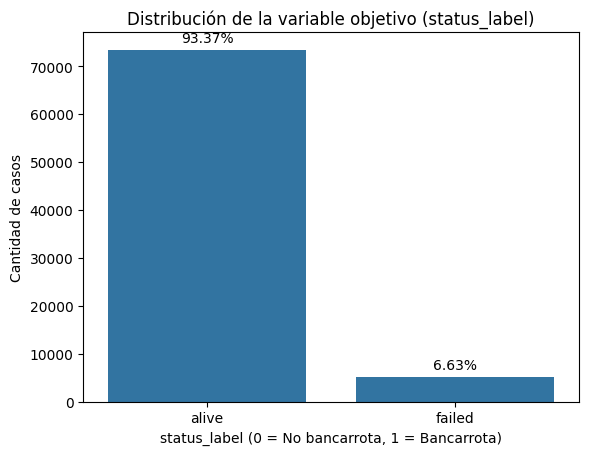

status_label
alive     73462
failed     5220
Name: count, dtype: int64


In [ ]:
# Histograma
# Dsitribucion de la variable que indica bancarrota o no.
ax = sns.countplot(x=target_var, data=df)
total = len(df)
plt.title(f"Distribución de la variable objetivo ({target_var})")
plt.xlabel(f"{target_var} (0 = No bancarrota, 1 = Bancarrota)")
plt.ylabel("Cantidad de casos")
# Anotar porcentaje sobre cada barra
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(
        f"{pct:.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.show()
print(df[target_var].value_counts())


In [ ]:
# Desvio standar y varianza de cada variable
stds = df[numeric_cols].std(numeric_only=True)
vars_ = df[numeric_cols].var(numeric_only=True)

dispersion = pd.DataFrame({"std": stds, "var": vars_})
dispersion = dispersion.sort_values(by="std", ascending=False)
display(dispersion)

,std,var
X8,18414.103647,3.390792e+08
X10,12917.944421,1.668733e+08
X9,11950.068842,1.428041e+08
X16,11950.068842,1.428041e+08
X18,10419.629038,1.085687e+08
X2,8930.484664,7.975356e+07
X17,8053.684902,6.486184e+07
X15,6369.159440,4.056619e+07
X1,3928.564794,1.543362e+07
X13,3774.703114,1.424838e+07


In [ ]:
# Verificacion valores faltantes.
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0] * 100
print(missing)
# Ninguna variable posee faltantes.

company_name    0.0
status_label    0.0
year            0.0
X1              0.0
X2              0.0
X3              0.0
X4              0.0
X5              0.0
X6              0.0
X7              0.0
X8              0.0
X9              0.0
X10             0.0
X11             0.0
X12             0.0
X13             0.0
X14             0.0
X15             0.0
X16             0.0
X17             0.0
X18             0.0
dtype: float64


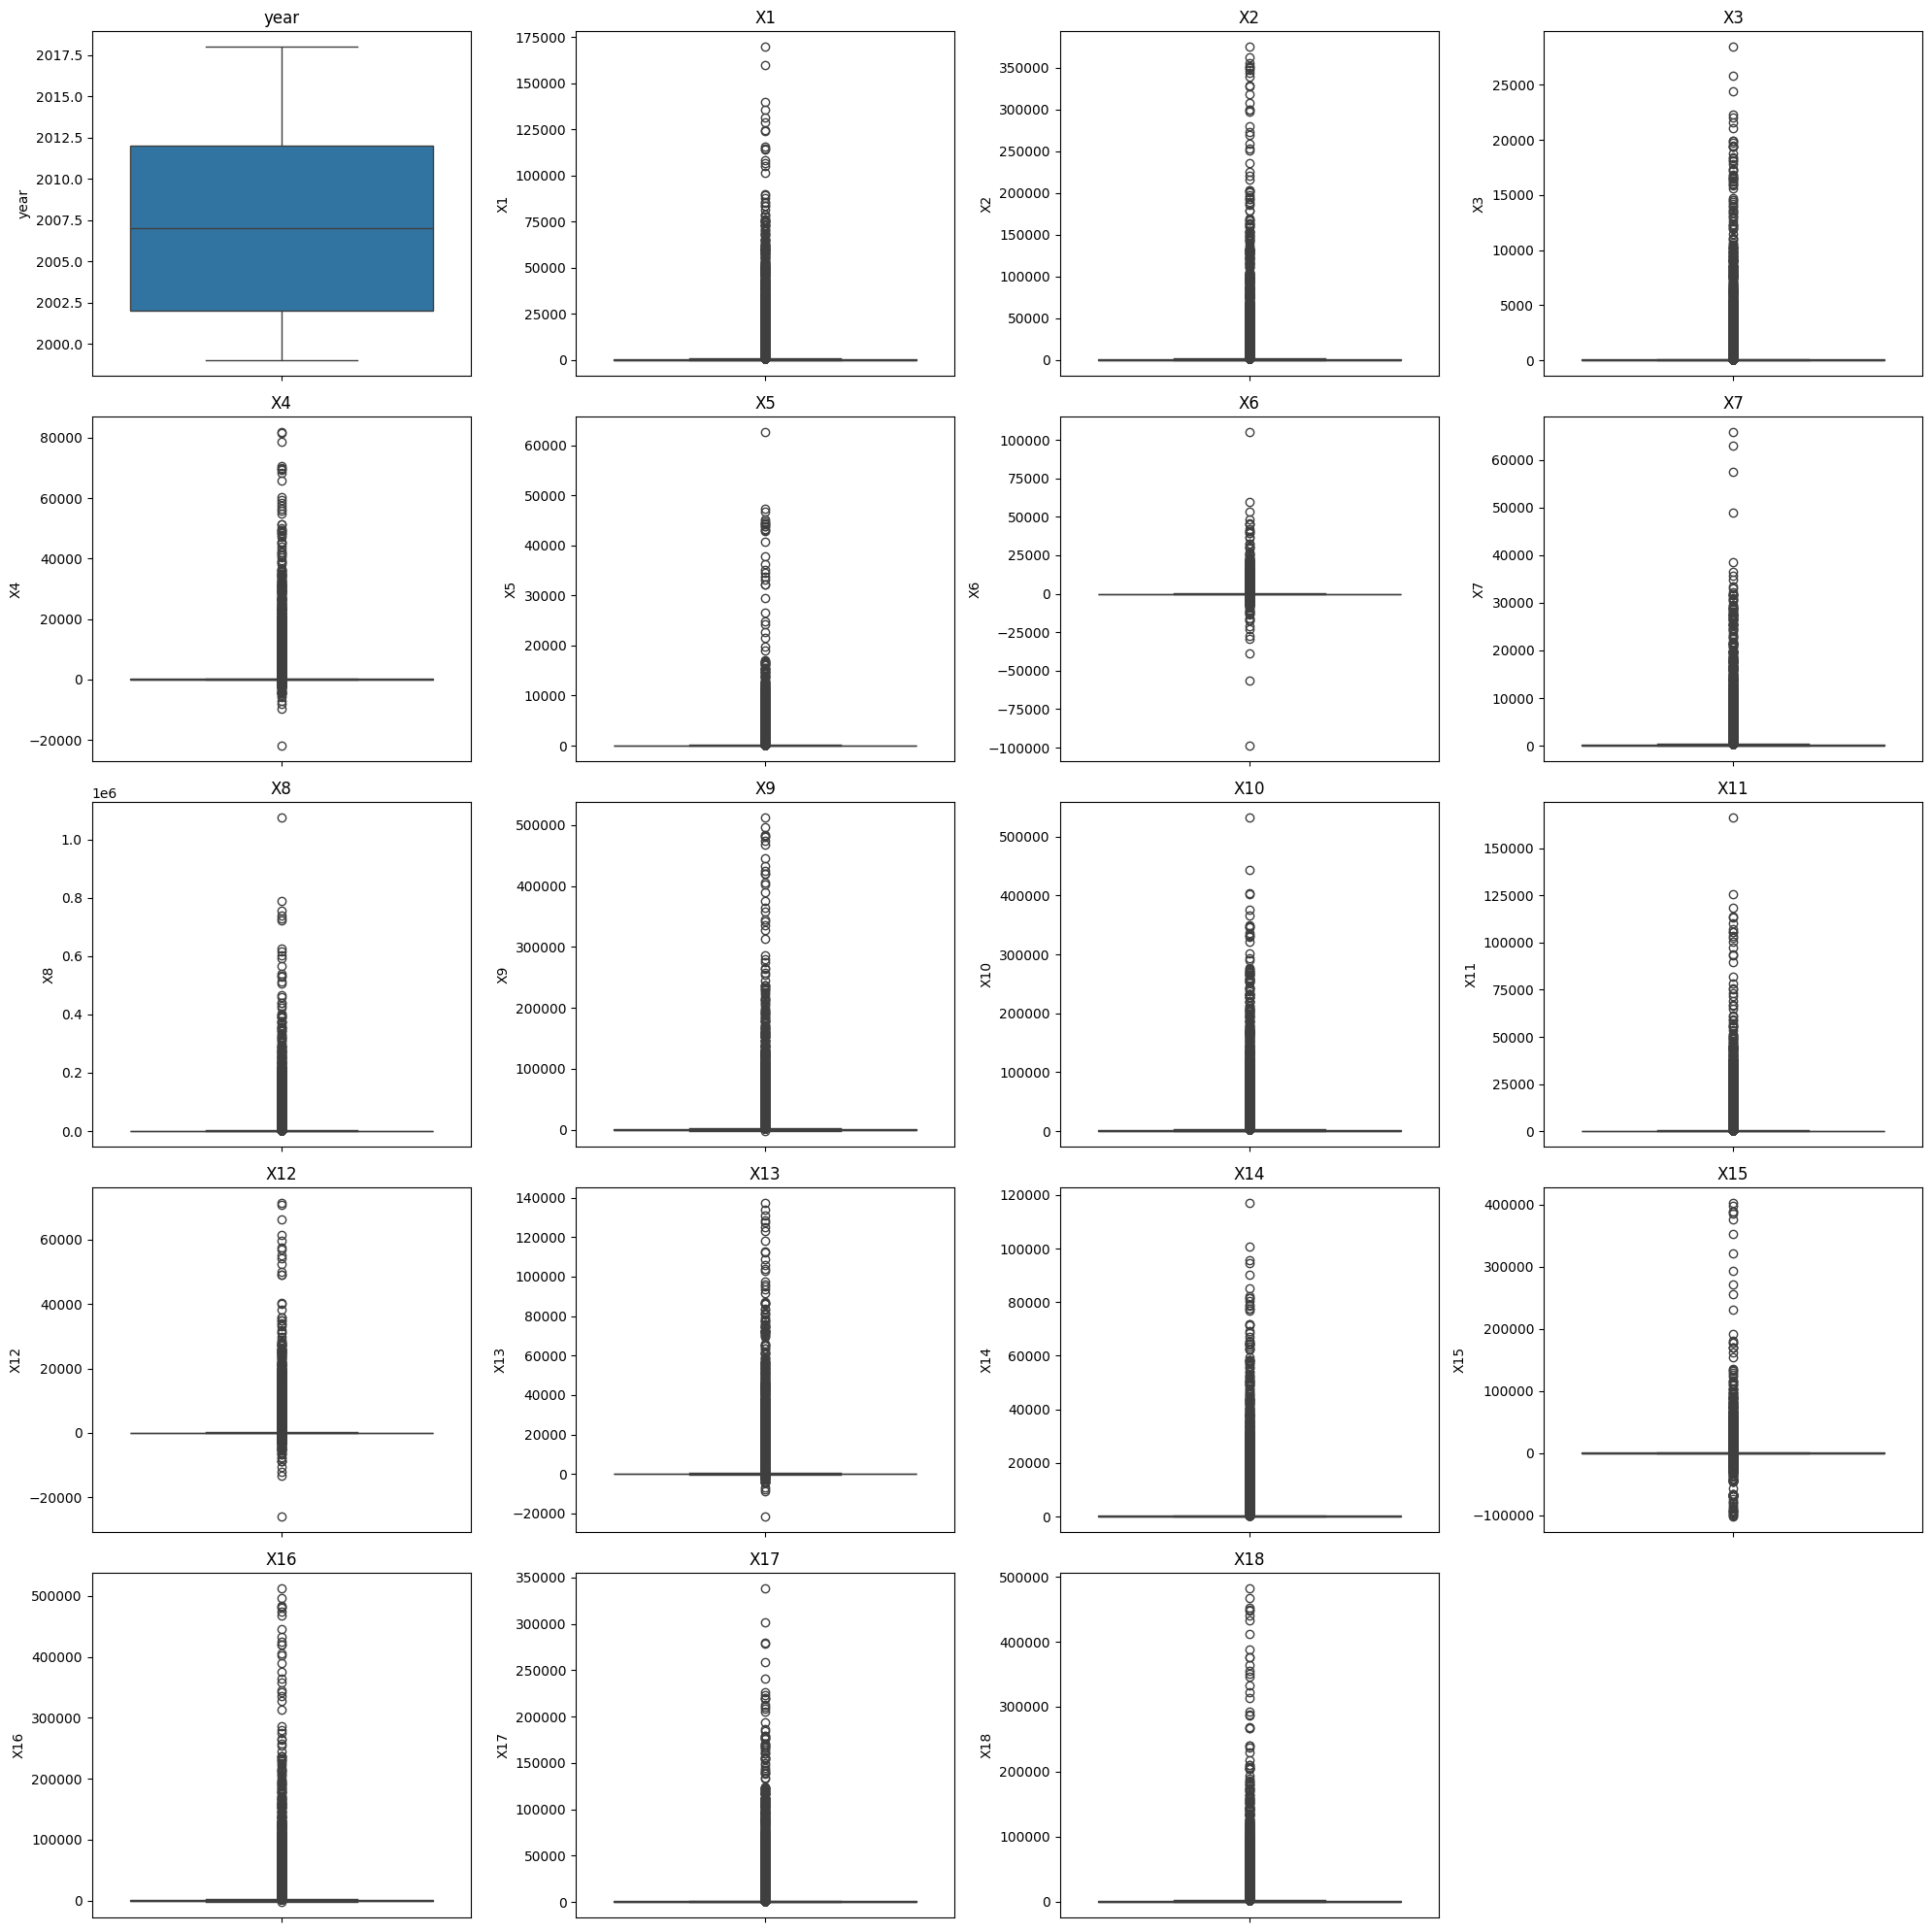

In [ ]:
# Boxplots (para detección de outliers)
def plot_boxplots(df, cols, n_cols=4):
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col], ax=ax)
        ax.set_title(col)
        ax.set_xlabel("")

    for ax in axes[len(cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Distribución de cada columna de manera individual
plot_boxplots(df, numeric_cols, n_cols=4)


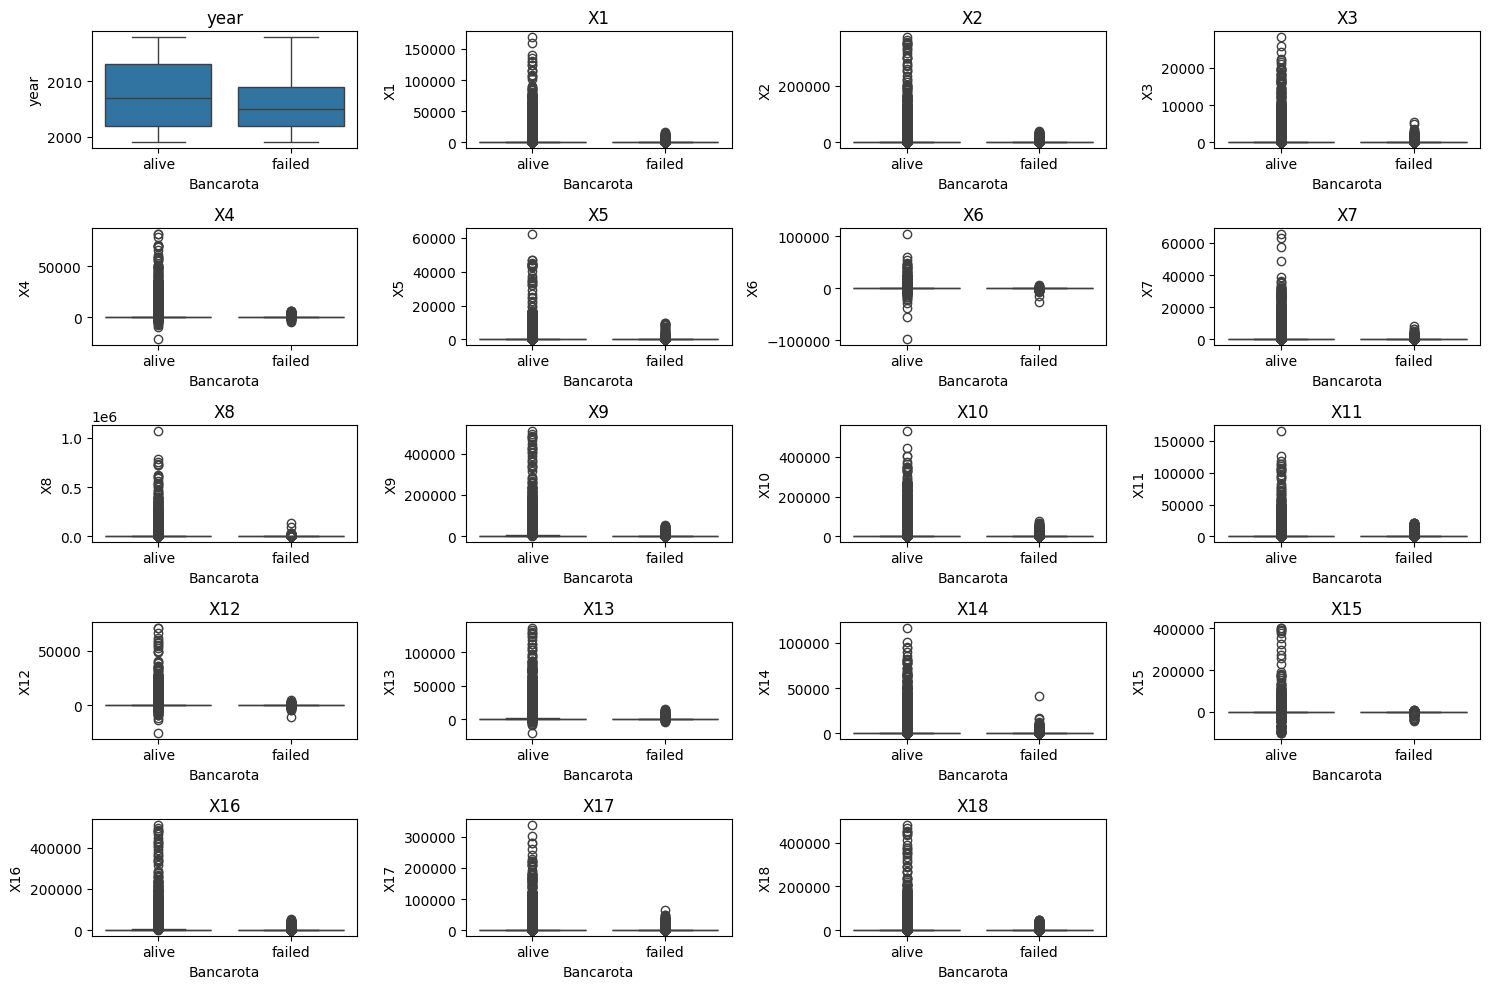

In [ ]:
# Boxplots 2
# Distribución de cada columna con respecto a cada valor de la variable objetivo (bancarrota si/no)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x=target_var, y=col, data=df)
    plt.title(col)
    plt.xlabel("Bancarota")

plt.tight_layout()
plt.show()

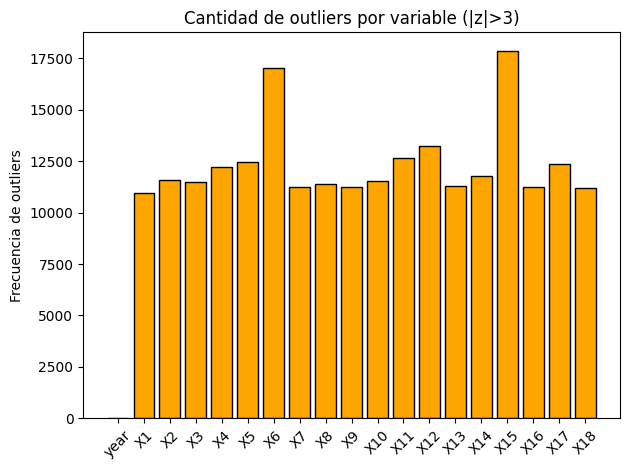

In [ ]:
# Rangos intercuartiles
out_counts = {}
for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  outliers = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
  out_counts[col] = outliers.sum()

# Cantidad de outliers por variable
plt.bar(out_counts.keys(), out_counts.values(), color="orange", edgecolor="black")
plt.title("Cantidad de outliers por variable (|z|>3)")
plt.xticks(rotation=45)
plt.ylabel("Frecuencia de outliers")
plt.tight_layout()
plt.show()

In [ ]:
# Resumen estadistico inicial
df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,78682.0,2007.506317,5.742768,1999.0000,1999.000000,1999.000000,2002.00000,2007.00000,2012.00000,2017.00000,2018.000000,2018.00
X1,78682.0,880.362485,3928.564794,-7.7600,0.066000,1.035000,18.92400,100.44950,431.52675,3507.98500,13626.760000,169662.00
X2,78682.0,1594.529029,8930.484664,-366.6450,0.031000,0.764000,17.03825,103.66100,634.54800,6130.97905,25674.380000,374623.00
X3,78682.0,121.234256,652.376804,0.0000,0.002000,0.059000,1.19200,7.92950,47.97175,483.00000,1804.380000,28430.00
X4,78682.0,376.759424,2012.023142,-21913.0000,-110.216750,-27.681850,-0.81100,15.03450,139.65525,1544.00000,6517.190000,81730.00
X5,78682.0,201.605717,1060.766096,0.0000,0.000000,0.000000,0.00000,7.02300,74.74725,841.00000,3421.704350,62567.00
X6,78682.0,129.382453,1265.532022,-98696.0000,-627.718930,-101.754350,-7.41575,1.61600,40.14425,588.29505,3047.570000,104821.00
X7,78682.0,286.832743,1335.978571,-0.0060,0.000000,0.041000,3.28125,22.82000,131.58050,1155.99500,4848.478940,65812.00
X8,78682.0,3414.354610,18414.103647,0.0001,0.582091,3.336305,34.98000,227.51185,1244.88995,12576.28537,60436.003881,1073390.54
X9,78682.0,2364.019706,11950.068842,-1964.9990,0.038000,0.726000,27.54850,186.59850,1046.40250,9432.91955,38053.090000,511729.00


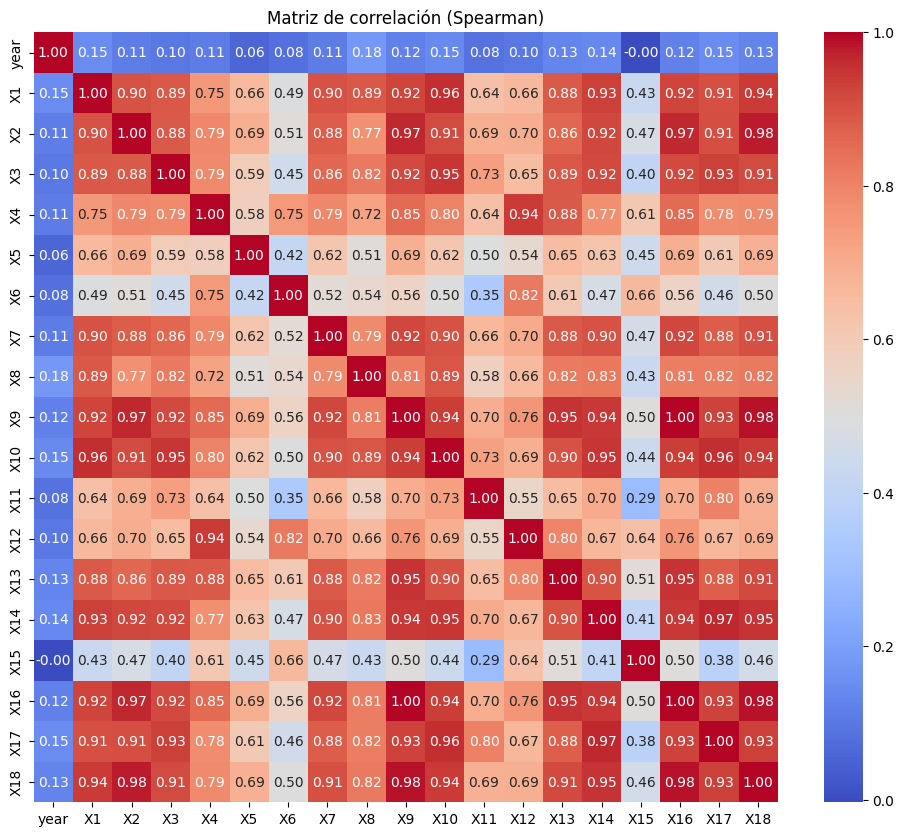

Posibles variables a eliminar


,Variable_1,Variable_2,Spearman_corr_abs
132,X9,X16,1.000000
134,X9,X18,0.984331
169,X16,X18,0.984331
50,X2,X18,0.977995
163,X14,X17,0.968604
48,X2,X16,0.966225
41,X2,X9,0.966225
141,X10,X17,0.960302
26,X1,X10,0.959776
164,X14,X18,0.951635


In [ ]:
# Matriz de correlacion
corr = df[numeric_cols].corr(method="spearman")  # Spearman es mejor que coef. correlacion de pearson en finanzas

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlación (Spearman)")
plt.show()

# Candidatas a ser eliminadas a partir de esta metrica (mayor a 0.9)
print("Posibles variables a eliminar")
# Correlación absoluta
corr_abs = corr.abs()

# Tomar solo la parte superior de la matriz (evita duplicados y diagonal)
upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# Extraer pares con correlación alta
threshold = 0.90  # descartar por correlacion solo variables que tengan un numero muy alto
high_corr_pairs = (
    upper
    .stack()                         # convierte a formato largo
    .reset_index()
)
high_corr_pairs.columns = ["Variable_1", "Variable_2", "Spearman_corr_abs"]
# Filtrar por umbral
high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Spearman_corr_abs"] >= threshold
]
# Ordenar por correlación descendente
high_corr_pairs = high_corr_pairs.sort_values(
    by="Spearman_corr_abs",
    ascending=False
)
high_corr_pairs


In [ ]:
# Importancia por variable en random forest. Para ver cuanto aporta cada una.
X = df[numeric_cols]
y = df[target_var]

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=numeric_cols)
importances.sort_values(ascending=False)


,0
year,0.075958
X8,0.073671
X6,0.065276
X15,0.064081
X3,0.058742
X17,0.055557
X7,0.054431
X1,0.052674
X11,0.052032
X13,0.050689


## 3. Preprocesamiento

In [ ]:
target_var = "status_label"
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Realizamos acciones en  base al analisis
# ELimina variables muy correlacionadas (redundantes)
cols_to_remove = ["X1", "X12", "X13", "X14", "X16", "X18"]
numeric_cols = [col for col in numeric_cols if col not in cols_to_remove]
# ELimina del dataset original
df.drop(columns=cols_to_remove, inplace=True)

# 3. Creación de modelos individuales

In [ ]:
RANDOM_STATE = 42    # Reproducibilidad (Colab)
POS_LABEL = "true"   # Si Bancarrota. Fijamos la clase positiva al valor de BANCARROTA (clase minoritaria)
NEG_LABEL = "false"  # No Bancarrota
THRESHOLD = 0.5
CALIBRATION_METHOD = "isotonic"

X = df[numeric_cols].copy()
y = df[target_var].copy()
# Mapear etiquetas originales a etiquetas más explícitas
y = y.map({"failed": POS_LABEL, "alive": NEG_LABEL})

## 3.1 Stratificacion del dataset

In [ ]:
# Split estratificado: train / validation / test (70/15/15)
X_traintotal, X_test, y_traintotal, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)
# De traintotal separamos validation (15% del total)
val_size_total = 0.15
val_size_rel = val_size_total / (1 - 0.15)

X_train, X_val, y_train, y_val = train_test_split(
    X_traintotal, y_traintotal,
    test_size=val_size_rel,
    stratify=y_traintotal,
    random_state=RANDOM_STATE
)

def _dist(name, y_series):
    counts = y_series.value_counts(dropna=False)
    props = (counts / len(y_series)).round(4)
    out = pd.DataFrame({"count": counts, "prop": props})
    out.index.name = f"{name}:{target_var}"
    return out

print("Shapes:")
print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

print("\nDistribución estratificada (muy similar entre splits):")
display(_dist("train", y_train))
display(_dist("val", y_val))
display(_dist("test", y_test))



Shapes:
train: (55076, 13)  val: (11803, 13)  test: (11803, 13)

Distribución estratificada (muy similar entre splits):


,count,prop
train:status_label,,
false,51422,0.9337
true,3654,0.0663


,count,prop
val:status_label,,
false,11020,0.9337
true,783,0.0663


,count,prop
test:status_label,,
false,11020,0.9337
true,783,0.0663


## 3.3 Escalado y desbalanceo

In [ ]:
# 1. Escalado de los datos: con RobustScaler mediante pipelines (y solo en el dataset de entrenamiento)

# 2. Tratamiento del desbalance usando class_weight (SIN balancear val/test)
#    Calculamos pesos desde y_train y lo pasamos a los modelos dentro de pipelines.

# Clases presentes en TRAIN (importante: solo train)
classes = np.array(sorted(y_train.unique()))
print("Clases en train:", classes)

# Pesos balanceados (solo a partir de y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, weights))

print("\nclass_weight calculado (solo train):")
print(class_weight_dict)

# Modelos que soportan class_weight directamente: LogisticRegression, LinearSVC/SVC, RandomForest.
# MLPClassifier NO soporta class_weight, pero sí admite sample_weight en .fit()

# Instancia Pipelines base para cada modelo individual

# REGRESION LOGISTICA
pipe_lr = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight=class_weight_dict,
        n_jobs=None  # LogisticRegression no siempre usa n_jobs
    ))
])

# SUPPORT VECTOR MACHINES
pipe_svc = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", SVC(
        probability=True,              # necesario para predict_proba
        class_weight=class_weight_dict,
        kernel="rbf",
        random_state=RANDOM_STATE
    ))
])

# RANDOM FOREST
pipe_rf = Pipeline([
    ("scaler", RobustScaler()),        # no estrictamente necesario para RF, pero mantenemos consistencia
    ("clf", RandomForestClassifier(
        n_estimators=500,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# PERCEPTRON MULTICAPA
pipe_mlp = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=False,
        n_iter_no_change=10
    ))
])
# sample_weight por fila (solo train)
# sample_weight_train = y_train.map(class_weight_dict).to_numpy()

print("\n Pesos calculados (donde apliquen)")
# print("Nota: MLP usará sample_weight_train luego, en su entrenamiento")


Clases en train: ['false' 'true']

class_weight calculado (solo train):
{np.str_('false'): np.float64(0.5355295398856521), np.str_('true'): np.float64(7.53639846743295)}

 Pesos calculados (donde apliquen)




```
# Esto tiene formato de código
```

## 3.4 Entrenamiento

In [ ]:
# Entrenamiento (train) + Calibración (train) + búsqueda de umbral óptimo (validation)
# 1) Dentro de TRAIN: split interno -> train_fit (entrenar) + train_cal (calibrar)
# 2) Con el modelo calibrado: usar VALIDATION para buscar umbral óptimo (apartir de F2 de bancarrota)

BETA = 2  # F2: prioriza recall (FN costoso) pero penaliza FP
THR_MIN = 0.15
THR_MAX = 0.50
THR_N = 36  # 0.15..0.50 paso 0.01

# ------------------------------------------------------------
# Helpers generales
# ------------------------------------------------------------
def proba_positive(estimator, X, pos_label=POS_LABEL):
    """Devuelve P(pos_label) usando predict_proba."""
    proba = estimator.predict_proba(X)
    idx = list(estimator.classes_).index(pos_label)
    return proba[:, idx]

def evaluate_on_validation(name, estimator, X_val, y_val, threshold=THRESHOLD):
    """Métricas en validation @ threshold sobre P(POS_LABEL)."""
    p = proba_positive(estimator, X_val, pos_label=POS_LABEL)
    y_pred = np.where(p >= threshold, POS_LABEL, NEG_LABEL)

    rec = recall_score(y_val, y_pred, pos_label=POS_LABEL)
    prec = precision_score(y_val, y_pred, pos_label=POS_LABEL, zero_division=0)
    f1 = f1_score(y_val, y_pred, pos_label=POS_LABEL, zero_division=0)
    f2 = fbeta_score(y_val, y_pred, pos_label=POS_LABEL, beta=BETA, zero_division=0)

    y_true_bin = (y_val == POS_LABEL).astype(int)
    ap = average_precision_score(y_true_bin, p)

    print(f"\n[{name}] VAL @ thr={threshold:.2f}")
    print(f"  recall({POS_LABEL}):    {rec:.4f}")
    print(f"  precision({POS_LABEL}): {prec:.4f}")
    print(f"  f1({POS_LABEL}):        {f1:.4f}")
    print(f"  f2({POS_LABEL}):        {f2:.4f}")
    print(f"  avg_precision(PR-AUC):  {ap:.4f}")
    return {"recall": rec, "precision": prec, "f1": f1, "f2": f2, "ap": ap}

def find_best_threshold_fbeta(estimator, X_val, y_val, beta=BETA):
    """Umbral óptimo en validation maximizando F-beta (por defecto F2) dentro de [THR_MIN, THR_MAX]."""
    thresholds = np.linspace(THR_MIN, THR_MAX, THR_N)
    p = proba_positive(estimator, X_val, pos_label=POS_LABEL)

    best = {
        "threshold": None,
        "f2": -1.0,
        "recall": -1.0,
        "precision": -1.0,
        "f1": -1.0,
        "cm": None,
    }

    for t in thresholds:
        y_pred = np.where(p >= t, POS_LABEL, NEG_LABEL)

        f2 = fbeta_score(y_val, y_pred, pos_label=POS_LABEL, beta=beta, zero_division=0)
        rec = recall_score(y_val, y_pred, pos_label=POS_LABEL)
        prec = precision_score(y_val, y_pred, pos_label=POS_LABEL, zero_division=0)
        f1 = f1_score(y_val, y_pred, pos_label=POS_LABEL, zero_division=0)

        # Prioridad: mayor F2. Desempate: mayor recall, luego mayor precision.
        if (
            f2 > best["f2"]
            or (f2 == best["f2"] and rec > best["recall"])
            or (f2 == best["f2"] and rec == best["recall"] and prec > best["precision"])
        ):
            best.update({
                "threshold": float(t),
                "f2": float(f2),
                "recall": float(rec),
                "precision": float(prec),
                "f1": float(f1),
                "cm": confusion_matrix(y_val, y_pred, labels=[POS_LABEL, NEG_LABEL]),
            })

    return best

# ------------------------------------------------------------
# Calibración usando split interno (SOLO en TRAIN)
# ------------------------------------------------------------
def fit_and_calibrate(
    base_estimator,
    X_train,
    y_train,
    *,
    method=CALIBRATION_METHOD,
    cal_size=0.2,
    random_state=RANDOM_STATE,
):
    """
    1) Split interno: X_train -> X_fit (entrenar) + X_cal (calibrar)
    2) Entrenar base_estimator con X_fit
    3) Calibrar con X_cal usando CalibratedClassifierCV(cv='prefit')
    """
    X_fit, X_cal, y_fit, y_cal = train_test_split(
        X_train, y_train,
        test_size=cal_size,
        stratify=y_train,
        random_state=random_state
    )

    est = base_estimator
    est.fit(X_fit, y_fit)

    cal = CalibratedClassifierCV(estimator=est, method=method, cv="prefit")
    cal.fit(X_cal, y_cal)

    return cal

# ------------------------------------------------------------
# Entrenar en train_fit + calibrar en train_cal
# Validación para baseline y umbral (F2)
# ------------------------------------------------------------

TRAIN_ORDER = [
    ("lr", pipe_lr),
    ("rf", pipe_rf),
    ("mlp", pipe_mlp),
    ("svc", pipe_svc),
]

models = {}
metrics_val_at_05 = {}
best_thresholds = {}
train_seconds = {}

for name, pipe in TRAIN_ORDER:
    t0 = time.time()
    model_cal = fit_and_calibrate(pipe, X_train, y_train, method=CALIBRATION_METHOD)
    t1 = time.time()

    m = evaluate_on_validation(f"{name.upper()} (cal)", model_cal, X_val, y_val, threshold=THRESHOLD)
    best = find_best_threshold_fbeta(model_cal, X_val, y_val, beta=BETA)

    models[name] = model_cal
    metrics_val_at_05[name] = m
    best_thresholds[name] = best
    train_seconds[name] = (t1 - t0)

    print(f"\n[{name}] tiempo train+cal: {train_seconds[name]:.2f}s")

print("\n=== Resumen tiempos (train+cal) ===")
for name, _ in TRAIN_ORDER:
    print(f"{name}: {train_seconds[name]:.2f}s")

print("\n=== Mejor umbral por modelo (validation, optimiza F2) ===")
for k, b in best_thresholds.items():
    print(
        f"{k}: thr={b['threshold']:.2f} | f2={b['f2']:.4f} | recall={b['recall']:.4f} | "
        f"precision={b['precision']:.4f} | f1={b['f1']:.4f}"
    )


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[LR (cal)] VAL @ thr=0.50
  recall(true):    0.0000
  precision(true): 0.0000
  f1(true):        0.0000
  f2(true):        0.0000
  avg_precision(PR-AUC):  0.0957

[lr] tiempo train+cal: 1.54s


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[RF (cal)] VAL @ thr=0.50
  recall(true):    0.1724
  precision(true): 0.6398
  f1(true):        0.2716
  f2(true):        0.2019
  avg_precision(PR-AUC):  0.3951

[rf] tiempo train+cal: 82.06s


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[MLP (cal)] VAL @ thr=0.50
  recall(true):    0.1124
  precision(true): 0.5641
  f1(true):        0.1874
  f2(true):        0.1338
  avg_precision(PR-AUC):  0.2789

[mlp] tiempo train+cal: 334.79s


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



[SVC (cal)] VAL @ thr=0.50
  recall(true):    0.0000
  precision(true): 0.0000
  f1(true):        0.0000
  f2(true):        0.0000
  avg_precision(PR-AUC):  0.1046

[svc] tiempo train+cal: 774.38s

=== Resumen tiempos (train+cal) ===
lr: 1.54s
rf: 82.06s
mlp: 334.79s
svc: 774.38s

=== Mejor umbral por modelo (validation, optimiza F2) ===
lr: thr=0.15 | f2=0.0142 | recall=0.0115 | precision=0.2308 | f1=0.0219
rf: thr=0.15 | f2=0.5071 | recall=0.5926 | precision=0.3216 | f1=0.4169
mlp: thr=0.17 | f2=0.3513 | recall=0.3665 | precision=0.3012 | f1=0.3306
svc: thr=0.17 | f2=0.0987 | recall=0.0907 | precision=0.1527 | f1=0.1138


## Analisis de thresholds por modelo

In [ ]:
# Tabla resumen por modelo (validation)

rows = []
for name, b in best_thresholds.items():
    rows.append({
        "model": name,
        "thr_best_val": b["threshold"],
        "f2": b["f2"],
        "recall": b["recall"],
        "precision": b["precision"],
        "f1": b["f1"],
    })

df_val_summary = pd.DataFrame(rows).sort_values(
    by=["f2", "recall", "precision"],
    ascending=False
)

display(df_val_summary)


,model,thr_best_val,f2,recall,precision,f1
1,rf,0.15,0.507104,0.592593,0.321552,0.416891
2,mlp,0.17,0.351285,0.366539,0.301154,0.330645
3,svc,0.17,0.098693,0.090677,0.152688,0.113782
0,lr,0.15,0.014191,0.011494,0.230769,0.021898


##4. Algoritmo de Ensamble

In [ ]:
# Ensamble Soft Voting ponderado (probabilidades calibradas)
# Pesos definidos a partir de F2 en validation (en vez de recall)

def ensemble_proba_positive(models_dict, weights_dict, X, pos_label=POS_LABEL):
    """Devuelve P(pos_label) del ensamble: suma ponderada de P(pos_label) de cada modelo."""
    p = None
    for name, model in models_dict.items():
        w = weights_dict.get(name, 0.0)
        if w <= 0:
            continue
        p_i = proba_positive(model, X, pos_label=pos_label)
        p = p_i * w if p is None else p + p_i * w
    return p

# Pesos automáticos según F2 (fallback si alguno es 0)
WEIGHT_METRIC = "f2"
raw = {k: max(v[WEIGHT_METRIC], 1e-6) for k, v in best_thresholds.items()}
s = sum(raw.values())
weights = {k: v / s for k, v in raw.items()}
print("Pesos iniciales (según F2):", weights)

# Probabilidades del ensamble en validation
p_ens_val = ensemble_proba_positive(models, weights, X_val, pos_label=POS_LABEL)
print("p_ens_val shape:", p_ens_val.shape)


Pesos iniciales (según F2): {'lr': 0.014610825104860179, 'rf': 0.5221020000749336, 'mlp': 0.36167485050879467, 'svc': 0.10161232431141153}
p_ens_val shape: (11803,)


In [ ]:
# Threshold óptimo del ensamble en validation (optimiza F2)
def find_best_threshold_from_probas_fbeta(p_pos, y_true, beta=BETA):
    thresholds = np.linspace(THR_MIN, THR_MAX, THR_N)

    best = {
        "threshold": None,
        "f2": -1.0,
        "recall": -1.0,
        "precision": -1.0,
        "f1": -1.0,
        "cm": None
    }

    for t in thresholds:
        y_pred = np.where(p_pos >= t, POS_LABEL, NEG_LABEL)

        f2 = fbeta_score(y_true, y_pred, pos_label=POS_LABEL, beta=beta, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=POS_LABEL)
        prec = precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)

        if (
            f2 > best["f2"]
            or (f2 == best["f2"] and rec > best["recall"])
            or (f2 == best["f2"] and rec == best["recall"] and prec > best["precision"])
        ):
            best.update({
                "threshold": float(t),
                "f2": float(f2),
                "recall": float(rec),
                "precision": float(prec),
                "f1": float(f1),
                "cm": confusion_matrix(y_true, y_pred, labels=[POS_LABEL, NEG_LABEL])
            })

    return best

best_threshold_ens = find_best_threshold_from_probas_fbeta(p_ens_val, y_val, beta=BETA)
print("Best ensemble threshold (val):", best_threshold_ens)


Best ensemble threshold (val): {'threshold': 0.15, 'f2': 0.5025415896487985, 'recall': 0.5555555555555556, 'precision': 0.3637123745819398, 'f1': 0.43961596766043454, 'cm': array([[  435,   348],
       [  761, 10259]])}


## 5. Evaluación en Test

In [ ]:
# Evaluación FINAL en TEST (una sola vez) usando pesos + threshold del ensamble
p_ens_test = ensemble_proba_positive(models, weights, X_test, pos_label=POS_LABEL)

thr = best_threshold_ens["threshold"]
y_test_pred = np.where(p_ens_test >= thr, POS_LABEL, NEG_LABEL)

print("\n=== TEST (FINAL) ===")
print("threshold:", thr)
print(classification_report(y_test, y_test_pred, labels=[POS_LABEL, NEG_LABEL], zero_division=0))
print("Confusion matrix [POS_LABEL, NEG_LABEL]:\n", confusion_matrix(y_test, y_test_pred, labels=[POS_LABEL, NEG_LABEL]))



=== TEST (FINAL) ===
threshold: 0.15
              precision    recall  f1-score   support

        true       0.37      0.59      0.46       783
       false       0.97      0.93      0.95     11020

    accuracy                           0.91     11803
   macro avg       0.67      0.76      0.70     11803
weighted avg       0.93      0.91      0.92     11803

Confusion matrix [POS_LABEL, NEG_LABEL]:
 [[  464   319]
 [  789 10231]]


## 6. Comparación y analisis

In [ ]:
# IMportancia por permutacion. Cambia al azar los variables de cada variable y compara si F2 decae al tener esa variable alterada.
# De esta manera, se ve que variables afectan mas o menos el desempeño en la prediccion final.

def f2_from_proba(p_pos, y_true, thr):
    y_pred = np.where(p_pos >= thr, POS_LABEL, NEG_LABEL)
    # F2 para la clase positiva (bankruptcy_true)
    return fbeta_score(y_true, y_pred, beta=BETA, pos_label=POS_LABEL, zero_division=0)

def permutation_importance_ensemble(
    models_dict, weights_dict, X, y, thr, feature_names,
    n_repeats=5, random_state=42
):
    rng = np.random.RandomState(random_state)

    # baseline
    p_base = ensemble_proba_positive(models_dict, weights_dict, X)
    base_score = f2_from_proba(p_base, y, thr)

    importances = []
    X_work = X.copy()

    for col in feature_names:
        print(f'Permutar {col}')
        scores = []
        for _ in range(n_repeats):
            # permutar SOLO una columna
            saved = X_work[col].to_numpy().copy()
            X_work[col] = rng.permutation(X_work[col].to_numpy())

            p_perm = ensemble_proba_positive(models_dict, weights_dict, X_work)
            s = f2_from_proba(p_perm, y, thr)
            scores.append(s)

            # restaurar
            X_work[col] = saved

        drop = base_score - np.mean(scores)
        importances.append({
            "feature": col,
            "importance_drop_f2": drop,
            "f2_baseline": base_score,
            "f2_perm_mean": float(np.mean(scores)),
            "f2_perm_std": float(np.std(scores))
        })

    df_imp = pd.DataFrame(importances).sort_values("importance_drop_f2", ascending=False)
    return df_imp

# ---- ejecutar en TEST (modelo final) ----
best_thr_ens = best_threshold_ens["threshold"]
df_permutation_importance = permutation_importance_ensemble(
    models, weights,
    X_test, y_test,
    thr=best_thr_ens,
    feature_names=numeric_cols,
    n_repeats=5,
    random_state=RANDOM_STATE
)

display(df_permutation_importance.head(20))


Permutar year
Permutar X2
Permutar X3
Permutar X4
Permutar X5
Permutar X6
Permutar X7
Permutar X8
Permutar X9
Permutar X10
Permutar X11
Permutar X15
Permutar X17


,feature,importance_drop_f2,f2_baseline,f2_perm_mean,f2_perm_std
7,X8,0.153771,0.529076,0.375305,0.008024
10,X11,0.149668,0.529076,0.379409,0.004670
11,X15,0.145705,0.529076,0.383372,0.004342
6,X7,0.141358,0.529076,0.387718,0.008277
12,X17,0.134415,0.529076,0.394661,0.012780
8,X9,0.133991,0.529076,0.395085,0.009760
2,X3,0.132633,0.529076,0.396443,0.002921
0,year,0.131296,0.529076,0.397780,0.007633
4,X5,0.124129,0.529076,0.404948,0.006128
9,X10,0.123985,0.529076,0.405091,0.002736


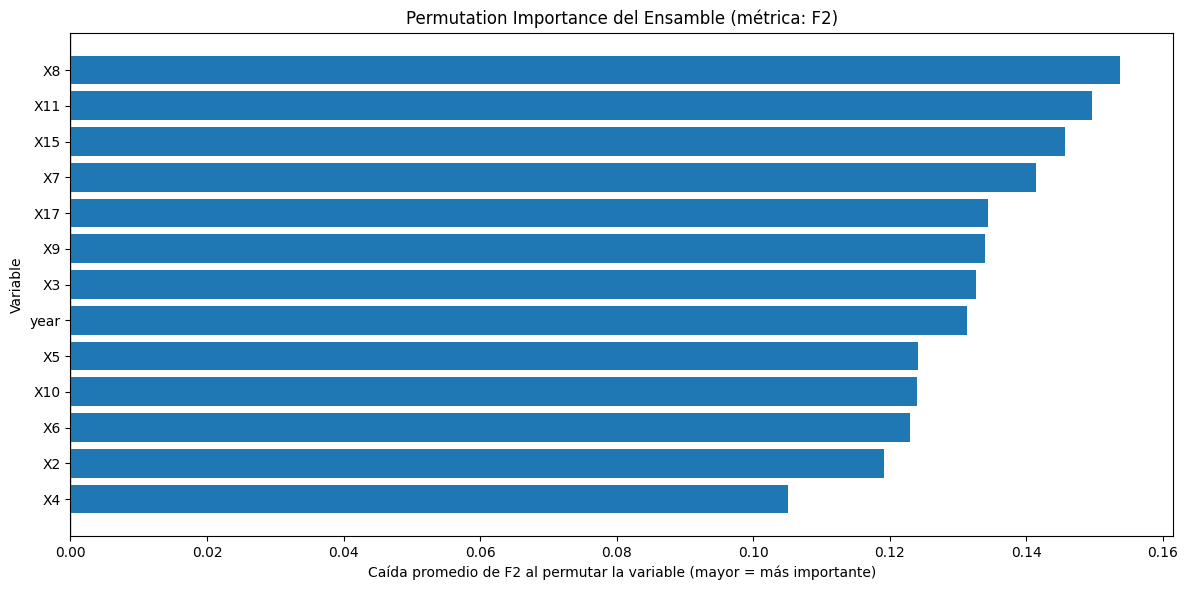

In [ ]:
# Graficamos

# Ordenar
df_plot = df_permutation_importance.sort_values("importance_drop_f2", ascending=False).reset_index(drop=True)
# Tamaño dinámico: muchas variables
n_features = len(df_plot)
fig_h = max(6, n_features * 0.25)
plt.figure(figsize=(12, fig_h))

# Bar plot horizontal (más legible con muchas variables)
y_pos = np.arange(n_features)
plt.barh(y_pos, df_plot["importance_drop_f2"].to_numpy())
plt.yticks(y_pos, df_plot["feature"].to_numpy())
plt.gca().invert_yaxis()  # la más importante arriba

plt.xlabel("Caída promedio de F2 al permutar la variable (mayor = más importante)")
plt.ylabel("Variable")
plt.title("Permutation Importance del Ensamble (métrica: F2)")

# Línea vertical en 0 para ver variables con aporte ~0 o negativo
plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()


In [ ]:
# -----------------------------
# Helpers
# -----------------------------
def compute_metrics_from_proba(p, y_true, threshold):
    y_pred = np.where(p >= threshold, POS_LABEL, NEG_LABEL)

    recall = recall_score(y_true, y_pred, pos_label=POS_LABEL)
    precision = precision_score(y_true, y_pred, pos_label=POS_LABEL, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=BETA, pos_label=POS_LABEL, zero_division=0)

    y_true_bin = (y_true == POS_LABEL).astype(int)
    pr_auc = average_precision_score(y_true_bin, p)
    roc_auc = roc_auc_score(y_true_bin, p)

    return recall, precision, f2, pr_auc, roc_auc

def ensemble_proba(models_dict, weights_dict, X):
    p = None
    for name, model in models_dict.items():
        w = weights_dict.get(name, 0.0)
        if w <= 0:
            continue
        p_i = proba_positive(model, X)
        p = p_i * w if p is None else p + p_i * w
    return p

# -----------------------------
# Construcción de tabla
# -----------------------------
results = []

# Modelos individuales
for name, model in models.items():
    p = proba_positive(model, X_test)
    thr = best_thresholds[name]["threshold"]

    recall, precision, f2, pr_auc, roc_auc = compute_metrics_from_proba(
        p, y_test, thr
    )

    results.append({
        "Model": name.upper(),
        "Recall (bankruptcy_true)": recall,
        "Precision": precision,
        "F2": f2,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    })

# Ensamble
p_ens = ensemble_proba(models, weights, X_test)
thr_ens = best_threshold_ens["threshold"]

recall, precision, f2, pr_auc, roc_auc = compute_metrics_from_proba(
    p_ens, y_test, thr_ens
)

results.append({
    "Model": "SOFT VOTING (Proposed)",
    "Recall (bankruptcy_true)": recall,
    "Precision": precision,
    "F2": f2,
    "PR-AUC": pr_auc,
    "ROC-AUC": roc_auc
})

# Dummy classifier
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)

p_dummy = dummy


In [ ]:
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values("F2", ascending=False)
df_results_sorted


,Model,Recall (bankruptcy_true),Precision,F2,PR-AUC,ROC-AUC
1,RF,0.628352,0.329538,0.531892,0.454467,0.884356
4,SOFT VOTING (Proposed),0.592593,0.370311,0.529076,0.508942,0.886545
2,MLP,0.434227,0.327238,0.407576,0.352624,0.819314
3,SVC,0.102171,0.155945,0.109739,0.111917,0.690229
0,LR,0.012771,0.256410,0.015768,0.103736,0.664341
